# 重构进行红移匹配之后进行计算ddr

这次想做的纯净一点，那我可以只包含bao的数据，且去掉DV的数据，从而保证完全的模型无关的重构。

In [1]:
#读取数据以及定义常量
import numpy as np
import pandas as pd
import utils
from gauss import GPR
import matplotlib.pyplot as plt
np.random.seed(42)
KERNEL_NU = 2.5
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif', 
    'mathtext.fontset': 'stix',
    'axes.linewidth': 1.2,
    'xtick.major.size': 5, 
    'xtick.major.width': 1.2,
    'ytick.major.size': 5,
    'ytick.major.width': 1.2,
    'legend.frameon': False,
    'legend.fontsize': 11,
})
MB_list = [-19.253, -19.384]
MB_err_list = [0.027, 0.052]
MB_name_list = ['R22', 'DB23']
#bao数据
z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)

mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
dm_rs, dh_rs = bao_val[mask_dm], bao_val[mask_dh]
z_exclude_dv = z_bao[mask_dh]
idx_use = np.where(mask_dh)[0]

In [2]:
# # 进行Hz的重构和z的匹配
# data = np.loadtxt('data/cc.txt')
# z_obs = data[:, 0]
# H_obs = data[:, 1]
# Cov_data = np.loadtxt('data/cc_cov.txt')
# gpr = GPR(l=1.0, sigma_f=100, kernel_name='rbf') 
# gpr.fit(z_obs, H_obs, Cov_data, optimize_method='emcee') 
# print(f"Optimized hyperparameters: l={gpr.l:.3f}, sigma_f={gpr.sigma_f:.3f}")
# z_pred = np.linspace(0, 2.5, 200)
# mu_pred, cov_pred = gpr.predict_with_uncertainty(z_pred)
# std_pred = np.sqrt(np.diag(cov_pred))
# hz_exclude_dv, hz_exclude_dv_cov = gpr.predict_with_uncertainty(z_exclude_dv)

# plt.figure(figsize=(8,5))
# plt.fill_between(z_pred, mu_pred -  std_pred, mu_pred + std_pred, alpha=0.3, color='b')
# plt.fill_between(z_pred, mu_pred -  2*std_pred, mu_pred + 2*std_pred, alpha=0.15, color='b')
# plt.plot(z_pred, mu_pred, color='blue')
# plt.errorbar(z_obs, H_obs, yerr=np.sqrt(np.diag(Cov_data)), fmt='o', color ='black')
# plt.errorbar(z_exclude_dv, hz_exclude_dv, yerr=np.sqrt(np.diag(hz_exclude_dv_cov)), fmt='o', color ='red')
# plt.xlabel('Redshift z')
# plt.ylabel('H(z) [km/s/Mpc]')
# plt.title('Gaussian Process Reconstruction of H(z)')
# plt.grid(True)
# plt.show()

To reconstruct the angular diameter distance $D_A(z)$ independent of the sound horizon $r_s$, we combine the transverse ($D_M/r_s$) and radial ($D_H/r_s$) BAO measurements with the reconstructed Hubble rate $H(z)$:
$$
D_A(z) = \frac{c}{(1+z)H(z)} \frac{D_M(z)/r_s}{D_H(z)/r_s}.
$$
The covariance matrix for $D_A$, denoted as $\mathbf{C}_{D_A}$, is obtained via the Jacobian error propagation method assuming independence between BAO measurements and the reconstructed $H(z)$:
$$
\mathbf{C}_{D_A} = \mathbf{J}_{BAO} \mathbf{C}_{BAO} \mathbf{J}_{BAO}^T + \mathbf{J}_{H} \mathbf{C}_{H} \mathbf{J}_{H}^T,
$$
where $\mathbf{C}_{BAO}$ and $\mathbf{C}_{H}$ are the covariance matrices for the BAO data and the reconstructed Hubble parameter, respectively. The Jacobian matrices are defined diagonally as:
$$
\mathbf{J}_{BAO} = \left[ \text{diag}\left(\frac{D_A}{D_M/r_s}\right), \; \text{diag}\left(-\frac{D_A}{D_H/r_s}\right) \right], \quad \mathbf{J}_{H} = \text{diag}\left(-\frac{D_A}{H(z)}\right).
$$
Finally, assuming the validity of the Etherington reciprocity theorem ($\eta=1$), we convert to luminosity distance $D_L(z) = (1+z)^2 D_A(z)$ and propagate the errors:
$$
\mathbf{C}_{D_L} = \mathbf{S} \mathbf{C}_{D_A} \mathbf{S}^T, \quad \text{with} \quad \mathbf{S} = \text{diag}\left((1+z)^2\right).
$$

In [3]:
h_match, h_cov = np.load("output/cc_baomatch_mean_GPR.npy"), np.load("output/cc_baomatch_cov_GPR.npy")
hz_exclude_dv, hz_exclude_dv_cov = h_match[idx_use], h_cov[np.ix_(idx_use, idx_use)]

In [4]:
c = 299792.458
da = dm_rs / dh_rs * c / (1 + z_exclude_dv) / hz_exclude_dv

idx = np.concatenate([np.where(mask_dm)[0], np.where(mask_dh)[0]])
j_bao = np.hstack([np.diag(da/dm_rs), np.diag(-da/dh_rs)])
j_hz = np.diag(-da/hz_exclude_dv)
da_cov = j_bao @ bao_cov[np.ix_(idx, idx)] @ j_bao.T + j_hz @ hz_exclude_dv_cov @ j_hz.T

scale = (1 + z_exclude_dv)**2
dl = da * scale
dl_cov = da_cov * np.outer(scale, scale)

print(f"DA: {da}\nDA_err: {np.sqrt(np.diag(da_cov))}")
print(f"DL: {dl}\nDL_err: {np.sqrt(np.diag(dl_cov))}")

DA: [1384.58788345 1545.28057715 1573.05411287 1677.68161147 1818.56925221
 2164.72836056]
DA_err: [103.39525232 108.03977375 103.40400717 112.39137356 149.75358609
 478.51277433]
DL: [ 3156.99883306  4497.44022184  5883.78238939  9037.73962594
 11221.03783988 24004.4563174 ]
DL_err: [ 235.7515148   314.44284695  386.76779864  605.45693742  924.0179631
 5306.18030327]


In [5]:
# 对mB作高斯过程回归
from gauss import GPR
sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn, mB_obs, err_sn = sn_df['zHD'].values, sn_df['m_b_corr'].values, sn_df['m_b_corr_err_DIAG'].values
mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")

# mask = (sn_df['IS_CALIBRATOR'] == 0) # 去掉了有chephid的样本
# z_sn = sn_df.loc[mask, 'zHD'].values
# mB_obs = sn_df.loc[mask, 'm_b_corr'].values

# idx_sn = sn_df.index[mask].values
# mB_cov = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
# mB_cov = mB_cov[np.ix_(idx_sn, idx_sn)]


# gpr = GPR(l=1.0, sigma_f=100, kernel_name='rbf') 
# gpr.fit(np.log(z_sn), mB_obs, mB_cov, optimize_method='minimize') 

# mB_baomatch_mean, mB_baomatch_cov = gpr.predict(np.log(z_bao))
# mB_baomatch_std = np.sqrt(np.diag(mB_baomatch_cov))
# np.save('output/mB_baomatch_mean_GPR_minimize.npy', mB_baomatch_mean)
# np.save('output/mB_baomatch_cov_GPR_minimize.npy', mB_baomatch_cov)
# print(f"Optimized hyperparameters: l={gpr.l:.3f}, sigma_f={gpr.sigma_f:.3f}")
mB_baomatch_mean, mB_baomatch_cov = np.load('output/mB_baomatch_mean_GPR.npy'), np.load('output/mB_baomatch_cov_GPR.npy')
mB_baomatch_mean, mB_baomatch_cov = mB_baomatch_mean[idx_use], mB_baomatch_cov[np.ix_(idx_use, idx_use)]

In [6]:
z_sn.shape

(1701,)

In [7]:
mB_baomatch_mean.shape

(6,)

Best MB: -19.4242 +/- 0.1061
Min Chi2: 3.10


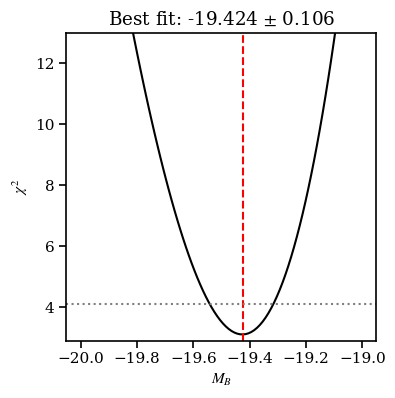

In [8]:
n_MC = 1000
MB_grid = np.linspace(-20, -19, 100)
chi2_list = []

mB_baomatch_samples = np.random.multivariate_normal(mB_baomatch_mean, mB_baomatch_cov, size=n_MC)

DL_bao_samples = np.random.multivariate_normal(dl, dl_cov, size=n_MC)


for MB_val in MB_grid:
    DL_sn_samples = 10**((mB_baomatch_samples - MB_val - 25) / 5)
    
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    
    diff = eta_mean - 1.0
    cinv = np.linalg.inv(eta_cov)
    chi2 = diff.T @ cinv @ diff
        
    chi2_list.append(chi2)

chi2_arr = np.array(chi2_list)
min_idx = np.argmin(chi2_arr)
best_MB = MB_grid[min_idx]
min_chi2 = chi2_arr[min_idx]

delta_chi2 = chi2_arr - min_chi2
sigma_region = MB_grid[delta_chi2 <= 1.0]
mb_err_low = best_MB - sigma_region[0]
mb_err_high = sigma_region[-1] - best_MB
best_mb_err = (mb_err_low + mb_err_high) / 2 # 取平均

print(f"Best MB: {best_MB:.4f} +/- {best_mb_err:.4f}")
print(f"Min Chi2: {min_chi2:.2f}")

plt.figure(figsize=(4, 4))
plt.plot(MB_grid, chi2_arr, 'black', label=r'$\chi^2$ Profile')
plt.axvline(best_MB, color='r', linestyle='--', label=f'Best $M_B$={best_MB:.3f}')
plt.axhline(min_chi2 + 1, color='grey', linestyle=':', label=r'$1\sigma$ region')
plt.xlabel(r'$M_B$')
plt.ylabel(r'$\chi^2$')
plt.ylim(min(chi2_arr)-0.2,13)
# plt.legend()
plt.title(f'Best fit: {best_MB:.3f} $\pm$ {best_mb_err:.3f}')
plt.savefig('fig/bestfit_GPR.pdf')
plt.show()


In [9]:
best_DL_sn_samples = 10**((mB_baomatch_samples - best_MB - 25) / 5)
best_eta_samples = best_DL_sn_samples / DL_bao_samples
best_eta_mean = np.mean(best_eta_samples, axis=0)
best_eta_cov = np.cov(best_eta_samples, rowvar=False)
best_DL_sn_mean = np.mean(best_DL_sn_samples, axis=0)
best_DL_sn_cov = np.cov(best_DL_sn_samples, rowvar=False)

In [10]:
#LCDM predict
z_plot = np.linspace(0.05, 2.5, 500)
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=67.4, Om0=0.315)
DL = cosmo.luminosity_distance(z_plot).value 

-19.253 5.500806414455613 0.4813592439081277
-19.384 3.21617840913926 0.7812659191416006


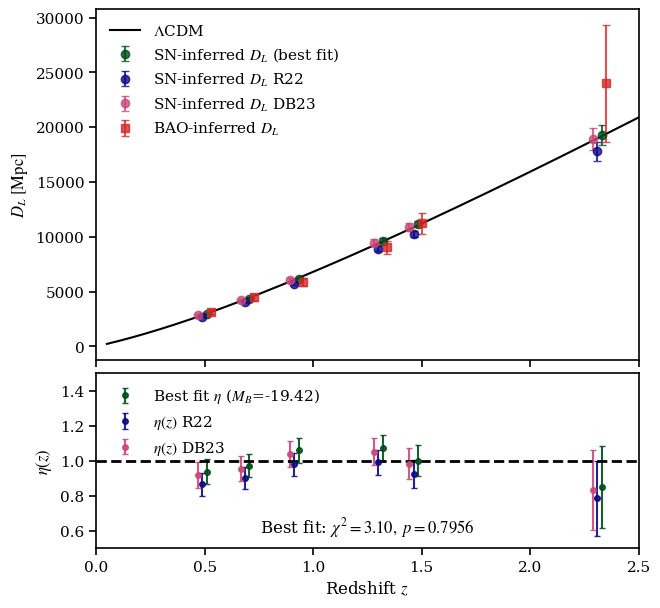

In [11]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.05}
)

ax1.plot(z_plot, DL, color='black', label=r'$\Lambda$CDM')

ax1.errorbar(
    z_exclude_dv, best_DL_sn_mean, np.sqrt(np.diag(best_DL_sn_cov)),
    fmt='o', label=rf'SN-inferred $D_L$ (best fit)', capsize=3, color="#004d1a", alpha=0.8
)

for i, (MB_val, MB_err, MB_name) in enumerate(zip(MB_list, MB_err_list, MB_name_list)):
    MB_samples = np.random.normal(MB_val, MB_err, n_MC)
    DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
    DL_sn_mean = np.mean(DL_sn_samples, axis=0)
    DL_sn_cov = np.cov(DL_sn_samples, rowvar=False)
    ax1.errorbar(
        z_exclude_dv-(i+1)*0.02, DL_sn_mean, np.sqrt(np.diag(DL_sn_cov)),
        fmt='o', label=rf'SN-inferred $D_L$ {MB_name}', capsize=3, alpha=0.8, color=plt.cm.plasma(i / len(MB_list))
    )

ax1.errorbar(
    z_exclude_dv+0.02, dl, np.sqrt(np.diag(dl_cov)),
    fmt='s', label=r'BAO-inferred $D_L$', capsize=3, color='#d62728', alpha=0.8
)

ax1.set_ylabel(r'$D_L\ \mathrm{[Mpc]}$', fontsize=12)
ax1.legend()

ax2.errorbar(
    z_exclude_dv, best_eta_mean, np.sqrt(np.diag(best_eta_cov)),
    fmt='o', ms=4, capsize=2, label=f'Best fit $\eta$ ($M_B$={best_MB:.2f})', alpha=0.9, color="#004d1a"
)

for i, (MB_val, MB_err, MB_name) in enumerate(zip(MB_list, MB_err_list, MB_name_list)):
    MB_samples = np.random.normal(MB_val, MB_err, n_MC)
    DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    chi2_val, p_val = utils.eta_chi2(eta_mean, eta_cov)
    print(MB_val, chi2_val, p_val)
    ax2.errorbar(
        z_exclude_dv-(i+1)*0.02, eta_mean, np.sqrt(np.diag(eta_cov)),
        fmt='o', ms=4, capsize=2, label=rf'$\eta(z)$ {MB_name}', alpha=0.9, color=plt.cm.plasma(i / len(MB_list))
    )

ax2.axhline(
    1.0, color='black', linestyle='--', linewidth=2
)


ax2.set_ylim(0.5, 1.5)
ax2.set_xlabel(r'Redshift $z$', fontsize=12)
ax2.set_ylabel(r'$\eta(z)$', fontsize=12)
ax2.legend(loc='upper left')
chi2_val, p_val = utils.eta_chi2(best_eta_mean, best_eta_cov)
plt.text(0.5, 0.05,
         rf'Best fit: $\chi^2 = {chi2_val:.2f},\ p = {p_val:.4f}$',
         ha='center', va='bottom',
         fontsize=12,
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round,pad=0.3',
                   facecolor='white', alpha=1, edgecolor='none'))
plt.xlim(0, 2.5)
plt.savefig('fig/measurement_GPR.pdf')
plt.show()

FKM Method

In [12]:
# import numpy as np
# import pandas as pd
# import emcee
# from scipy.interpolate import PchipInterpolator
# from scipy.optimize import minimize
# import utils

# np.random.seed(42)

# z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
# bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
# z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
# mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
# z_exclude_dv = z_bao[mask_dh] # BAO nodes

# data = np.loadtxt('data/cc.txt')
# z_cc, H_cc = data[:, 0], data[:, 1]
# H_cov = np.loadtxt('data/cc_cov.txt')

# z_knots = np.concatenate(([0.0], z_exclude_dv)) # [0.0, 0.38, ..., 2.33]
# n_dim = len(z_knots)
# inv_cc_cov = np.linalg.inv(H_cov)

# hz_fiducial = 70.0 * np.sqrt(0.3 * (1 + z_knots)**3 + 0.7)
# def log_prior(theta):

#     if np.any(theta <= 0): return -np.inf
    
#     if np.any(np.diff(theta) <= 0):
#         return -np.inf
    
#     h_last = theta[-1] 
#     h_prev = theta[-2] 
#     h_prev2 = theta[-3] 
    
#     z_last = z_knots[-1]
#     z_prev = z_knots[-2]
#     z_prev2 = z_knots[-3]
    
#     slope_prev = (h_prev - h_prev2) / (z_prev - z_prev2)
#     slope_curr = (h_last - h_prev) / (z_last - z_prev)
    

#     delta_slope = slope_curr - slope_prev
#     sigma_slope = 1.0 * np.abs(slope_prev) + 5.0
    
#     lp = -0.5 * (delta_slope / sigma_slope)**2
    
#     return lp

# def log_likelihood(theta):
#     lp = log_prior(theta)
#     if not np.isfinite(lp): return -np.inf
    
#     # PCHIP 插值
#     interp = PchipInterpolator(z_knots, theta)
#     model_h = interp(z_cc)
    
#     # Chi2 计算
#     diff = model_h - H_cc
#     chi2 = diff @ inv_cc_cov @ diff
#     return -0.5 * chi2 + lp

# n_walkers = 32
# n_steps = 10000
# burn_in = 1000

# p0 = hz_fiducial + 5.0 * np.random.randn(n_walkers, n_dim)

# print("Running MCMC ...")
# sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_likelihood)
# sampler.run_mcmc(p0, n_steps, progress=True)

# flat_samples = sampler.get_chain(discard=burn_in, flat=True)

# h_bao_samples = flat_samples[:, 1:] 

# hz_mean = np.mean(h_bao_samples, axis=0)
# hz_cov = np.cov(h_bao_samples, rowvar=False)

# print("\nResult at z=2.33 (Last Node):")
# print(f"Mean: {hz_mean[-1]:.2f}, Err: {np.sqrt(hz_cov[-1,-1]):.2f}")
# print(f"Fiducial LCDM was: {hz_fiducial[-1]:.2f}")
# print(sampler.get_autocorr_time())


In [13]:
mB_baomatch_mean, mB_baomatch_cov = np.load('output/mB_baomatch_mean_FKM.npy'), np.load('output/mB_baomatch_cov_FKM.npy')
mB_baomatch_mean, mB_baomatch_cov= mB_baomatch_mean[idx_use], mB_baomatch_cov[np.ix_(idx_use, idx_use)]
h_match, h_cov = np.load("output/cc_baomatch_mean_FKM.npy"), np.load("output/cc_baomatch_cov_FKM.npy")
hz_exclude_dv, hz_exclude_dv_cov = h_match[idx_use], h_cov[np.ix_(idx_use, idx_use)]

In [14]:
c = 299792.458
da = dm_rs / dh_rs * c / (1 + z_exclude_dv) / hz_exclude_dv

idx = np.concatenate([np.where(mask_dm)[0], np.where(mask_dh)[0]])
j_bao = np.hstack([np.diag(da/dm_rs), np.diag(-da/dh_rs)])
j_hz = np.diag(-da/hz_exclude_dv)
da_cov = j_bao @ bao_cov[np.ix_(idx, idx)] @ j_bao.T + j_hz @ hz_exclude_dv_cov @ j_hz.T

scale = (1 + z_exclude_dv)**2
dl = da * scale
dl_cov = da_cov * np.outer(scale, scale)

print(f"DA: {da}\nDA_err: {np.sqrt(np.diag(da_cov))}")
print(f"DL: {dl}\nDL_err: {np.sqrt(np.diag(dl_cov))}")

DA: [1434.9380514  1637.72358307 1488.19918526 1657.38455278 1761.72466
 1839.50245517]
DA_err: [113.283293   138.28354077 132.8660604  116.8504609  141.52099058
 401.692218  ]
DL: [ 3271.80225099  4766.48967422  5566.39475179  8928.39853862
 10870.29215371 20398.05877514]
DL_err: [ 258.29723638  402.46539525  496.96636623  629.47822371  873.22074124
 4454.32483617]


In [15]:
mB_baomatch_samples = np.random.multivariate_normal(mB_baomatch_mean, mB_baomatch_cov, size=n_MC)

DL_bao_samples = np.random.multivariate_normal(dl, dl_cov, size=n_MC)

In [16]:
# import numpy as np
# import pandas as pd
# import emcee
# from scipy.interpolate import PchipInterpolator
# from scipy.optimize import minimize
# import utils

# np.random.seed(42)

# z_bao, bao_val, bao_type = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_mean.txt', unpack=True, dtype=str)
# bao_cov = np.loadtxt('data/desi_gaussian_bao_ALL_GCcomb_cov.txt')
# z_bao, bao_val = z_bao.astype(float), bao_val.astype(float)
# mask_dm, mask_dh = (bao_type == 'DM_over_rs'), (bao_type == 'DH_over_rs')
# z_exclude_dv = z_bao[mask_dh] # BAO nodes

# sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
# mask = (sn_df['IS_CALIBRATOR'] == 0)
# z_sn = sn_df.loc[mask, 'zHD'].values
# mB_obs = sn_df.loc[mask, 'm_b_corr'].values

# idx_sn = sn_df.index[mask].values
# mB_cov_full = utils.read_cov("data/Pantheon+SH0ES_STAT+SYS.cov")
# mB_cov = mB_cov_full[np.ix_(idx_sn, idx_sn)]
# inv_mB_cov = np.linalg.inv(mB_cov)


# z_knots = np.concatenate(([0.005], z_exclude_dv))
# m_cp_init = np.interp(z_knots, z_sn, mB_obs)
# res = minimize(lambda p: -utils.ln_posterior(p, z_sn, mB_obs, inv_mB_cov, z_knots), m_cp_init, method='L-BFGS-B')
# print(res.x)

# def log_likelihood(theta):
#     # PCHIP 插值
#     interp = PchipInterpolator(np.log(z_knots), theta)
#     mB_model = interp(np.log(z_sn))
    
#     # Chi2 计算
#     diff = mB_model - mB_obs
#     chi2 = diff @ inv_mB_cov @ diff
#     return -0.5 * chi2# 加上先验

# # --- MCMC Setup ---
# n_walkers = 32
# n_steps = 6000 # 外推需要跑久一点让它收敛
# burn_in = 1000

# # 初始位置在 Fiducial 附近扰动
# p0 = res.x + 1e-4  * np.random.randn(n_walkers, n_dim)

# print("Running MCMC ...")
# sampler = emcee.EnsembleSampler(n_walkers, n_dim, log_likelihood)
# sampler.run_mcmc(p0, n_steps, progress=True)

# # --- Process ---
# flat_samples = sampler.get_chain(discard=burn_in, flat=True)
# # 只要 BAO 节点 (去掉 z=0)
# mB_bao_samples = flat_samples[:, 1:] 

# mB_baomatch_mean = np.mean(mB_bao_samples, axis=0)
# mB_baomatch_cov = np.cov(mB_bao_samples, rowvar=False)

# print(sampler.get_autocorr_time())


Best MB: -19.4444 +/- 0.1061
Min Chi2: 8.57


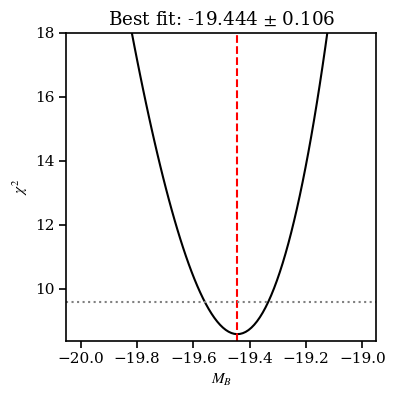

In [17]:
n_MC = 1000
MB_grid = np.linspace(-20, -19, 100)
chi2_list = []

for MB_val in MB_grid:
    DL_sn_samples = 10**((mB_baomatch_samples - MB_val - 25) / 5)
    
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    
    diff = eta_mean - 1.0
    cinv = np.linalg.inv(eta_cov)
    chi2 = diff.T @ cinv @ diff
        
    chi2_list.append(chi2)

chi2_arr = np.array(chi2_list)
min_idx = np.argmin(chi2_arr)
best_MB = MB_grid[min_idx]
min_chi2 = chi2_arr[min_idx]

delta_chi2 = chi2_arr - min_chi2
sigma_region = MB_grid[delta_chi2 <= 1.0]
mb_err_low = best_MB - sigma_region[0]
mb_err_high = sigma_region[-1] - best_MB
best_mb_err = (mb_err_low + mb_err_high) / 2 # 取平均

print(f"Best MB: {best_MB:.4f} +/- {best_mb_err:.4f}")
print(f"Min Chi2: {min_chi2:.2f}")

plt.figure(figsize=(4, 4))
plt.plot(MB_grid, chi2_arr, 'black', label=r'$\chi^2$ Profile')
plt.axvline(best_MB, color='r', linestyle='--', label=f'Best $M_B$={best_MB:.3f}')
plt.axhline(min_chi2 + 1, color='grey', linestyle=':', label=r'$1\sigma$ region')
plt.xlabel(r'$M_B$')
plt.ylabel(r'$\chi^2$')
plt.ylim(min(chi2_arr)-0.2,18)
# plt.legend()
plt.title(f'Best fit: {best_MB:.3f} $\pm$ {best_mb_err:.3f}')
plt.savefig('fig/bestfit_FKM.pdf')
plt.show()


In [18]:
best_DL_sn_samples = 10**((mB_baomatch_samples - best_MB - 25) / 5)
best_eta_samples = best_DL_sn_samples / DL_bao_samples
best_eta_mean = np.mean(best_eta_samples, axis=0)
best_eta_cov = np.cov(best_eta_samples, rowvar=False)
best_DL_sn_mean = np.mean(best_DL_sn_samples, axis=0)
best_DL_sn_cov = np.cov(best_DL_sn_samples, rowvar=False)

-19.253 11.57598315676657 0.07212476459068012
-19.384 8.85265962907939 0.18203552783151827


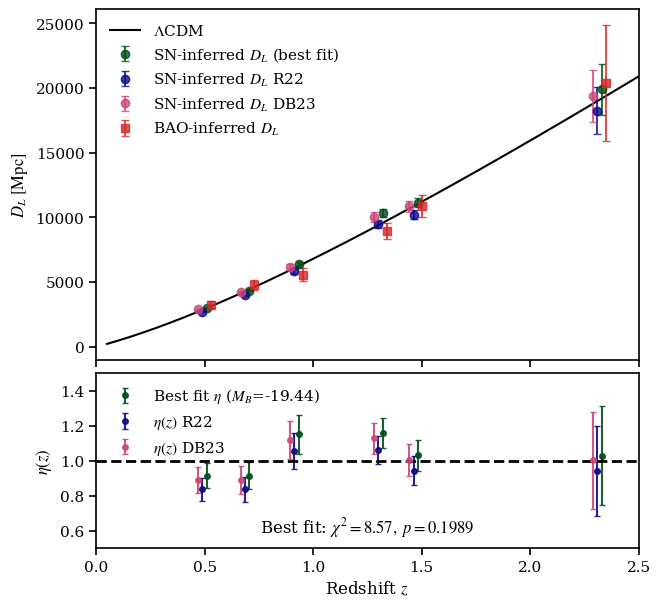

In [19]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7, 7),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.05}
)

ax1.plot(z_plot, DL, color='black', label=r'$\Lambda$CDM')

ax1.errorbar(
    z_exclude_dv, best_DL_sn_mean, np.sqrt(np.diag(best_DL_sn_cov)),
    fmt='o', label=rf'SN-inferred $D_L$ (best fit)', capsize=3, color="#004d1a", alpha=0.8
)

for i, (MB_val, MB_err, MB_name) in enumerate(zip(MB_list, MB_err_list, MB_name_list)):
    MB_samples = np.random.normal(MB_val, MB_err, n_MC)
    DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
    DL_sn_mean = np.mean(DL_sn_samples, axis=0)
    DL_sn_cov = np.cov(DL_sn_samples, rowvar=False)
    ax1.errorbar(
        z_exclude_dv-(i+1)*0.02, DL_sn_mean, np.sqrt(np.diag(DL_sn_cov)),
        fmt='o', label=rf'SN-inferred $D_L$ {MB_name}', capsize=3, alpha=0.8, color=plt.cm.plasma(i / len(MB_list))
    )

ax1.errorbar(
    z_exclude_dv+0.02, dl, np.sqrt(np.diag(dl_cov)),
    fmt='s', label=r'BAO-inferred $D_L$', capsize=3, color='#d62728', alpha=0.8
)

ax1.set_ylabel(r'$D_L\ \mathrm{[Mpc]}$', fontsize=12)
ax1.legend()

ax2.errorbar(
    z_exclude_dv, best_eta_mean, np.sqrt(np.diag(best_eta_cov)),
    fmt='o', ms=4, capsize=2, label=f'Best fit $\eta$ ($M_B$={best_MB:.2f})', alpha=0.9, color="#004d1a"
)

for i, (MB_val, MB_err, MB_name) in enumerate(zip(MB_list, MB_err_list, MB_name_list)):
    MB_samples = np.random.normal(MB_val, MB_err, n_MC)
    DL_sn_samples = 10**((mB_baomatch_samples - MB_samples[:, np.newaxis] - 25) / 5)
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_cov = np.cov(eta_samples, rowvar=False)
    chi2_val, p_val = utils.eta_chi2(eta_mean, eta_cov)
    print(MB_val, chi2_val, p_val)
    ax2.errorbar(
        z_exclude_dv-(i+1)*0.02, eta_mean, np.sqrt(np.diag(eta_cov)),
        fmt='o', ms=4, capsize=2, label=rf'$\eta(z)$ {MB_name}', alpha=0.9, color=plt.cm.plasma(i / len(MB_list))
    )

ax2.axhline(
    1.0, color='black', linestyle='--', linewidth=2
)


ax2.set_ylim(0.5, 1.5)
ax2.set_xlabel(r'Redshift $z$', fontsize=12)
ax2.set_ylabel(r'$\eta(z)$', fontsize=12)
ax2.legend(loc='upper left')
chi2_val, p_val = utils.eta_chi2(best_eta_mean, best_eta_cov)
plt.text(0.5, 0.05,
         rf'Best fit: $\chi^2 = {chi2_val:.2f},\ p = {p_val:.4f}$',
         ha='center', va='bottom',
         fontsize=12,
         transform=plt.gca().transAxes,
         bbox=dict(boxstyle='round,pad=0.3',
                   facecolor='white', alpha=1, edgecolor='none'))
plt.xlim(0, 2.5)
plt.savefig('fig/measurement_FKM.pdf')
plt.show()